## Objective


 **Develop a Student Depression Prediction Model using machine learning, deployed via Streamlit for an interactive and user-friendly self-assessment tool. The model will evaluate academic pressure, sleep patterns, work stress, and well-being to predict mental health risks.**

Key Focus:
✅ Accurate & interpretable predictions
✅ Seamless Streamlit integration
✅ User-friendly self-assessment
✅ Efficient & scalable design

In [1]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report
import xgboost as xgb
import shap
import pickle
import warnings
warnings.filterwarnings(action='ignore')


### Data Preparation

In [2]:
# Importing CSV Data
data = pd.read_csv("student_depression_data.csv")

### Data Cleaning & Preprocessing

In [3]:
# Check and Drop Duplicates
data = data.drop_duplicates()

# Check for inconsistent values in columns and replace/handle
data['Dietary Habits'] = data['Dietary Habits'].replace(["Unhealthy", "Healthy", "Moderate"], ["Unhealthy", "Healthy", "Moderate"])

# Ensure no negative or unrealistic values in columns like Age and CGPA
data = data[data['Age'] > 0]
data = data[data['CGPA'] > 0]

### Handle Missing Values

In [4]:
# Check for missing values
data.isnull().sum()

# For numerical columns, use the median to impute missing values
data['Age'] = data['Age'].fillna(data['Age'].median())
data['CGPA'] = data['CGPA'].fillna(data['CGPA'].median())

# For categorical columns, use the mode to fill missing values
data['Dietary Habits'] = data['Dietary Habits'].fillna(data['Dietary Habits'].mode()[0])

In [5]:
# Drop rows with missing values
data_cleaned = data.dropna()

# Check if there are any missing values remaining
print(data_cleaned.isnull().sum())

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64


### Normalization

In [6]:
# Encode 'Gender', 'Dietary Habits', 'Degree', 'Family History of Mental Illness' using Label Encoding
label_encoder = LabelEncoder()
data['Gender'] = label_encoder.fit_transform(data['Gender'])
data['Dietary Habits'] = label_encoder.fit_transform(data['Dietary Habits'])
data['Degree'] = label_encoder.fit_transform(data['Degree'])
data['Family History of Mental Illness'] = label_encoder.fit_transform(data['Family History of Mental Illness'])

### Exploratory Data Analysis (EDA)

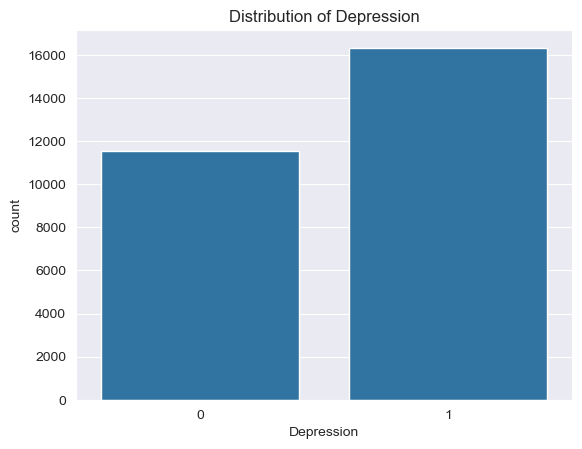

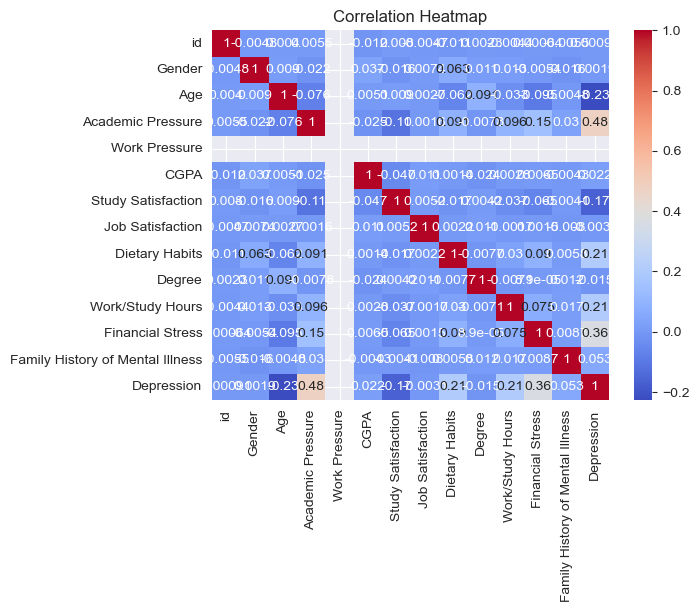

In [7]:
# Visualize the distribution of 'Depression'
sns.countplot(x='Depression', data=data)
plt.title('Distribution of Depression')
plt.show()

# Select only numeric columns for correlation
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# Check correlation between numeric columns
correlation = numeric_data.corr()

# Plot the heatmap of the correlation matrix
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Text(0.5, 0, 'Age')

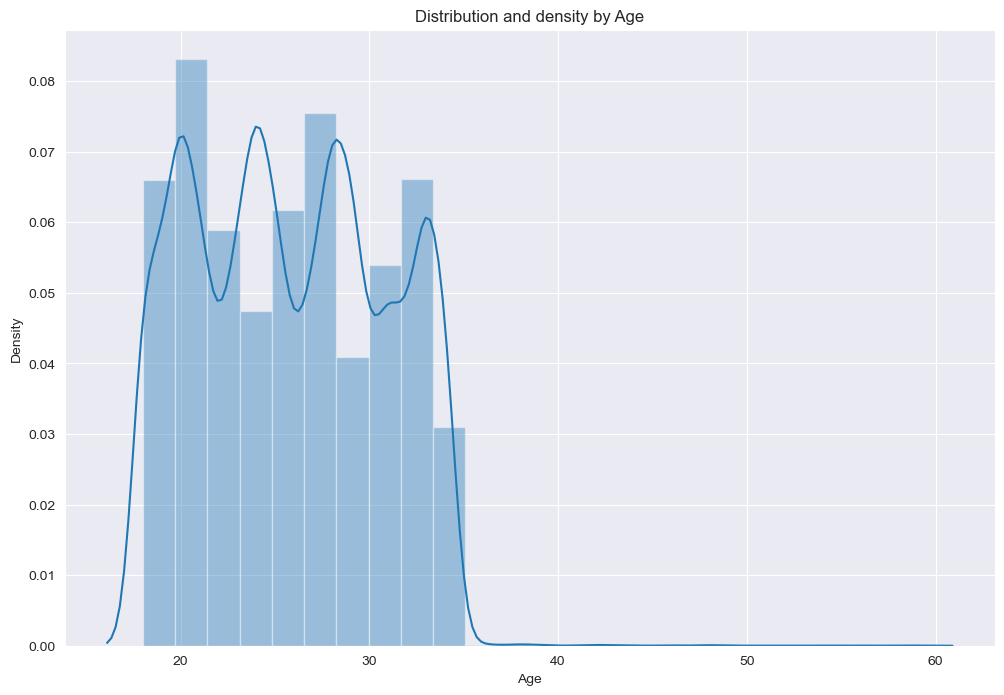

In [8]:
# Distribution and density by Age
plt.figure(figsize=(12,8))
sns.distplot(data["Age"], bins=24)
plt.title("Distribution and density by Age")
plt.xlabel("Age")

### Feature Engineering

In [9]:
X = data.drop(columns=['Depression', 'id'])  # Drop the target column
y = data['Depression']

In [10]:
label_encoder = LabelEncoder()

# Apply LabelEncoder to columns with string values
X['Gender'] = label_encoder.fit_transform(X['Gender'])

X = pd.get_dummies(X, drop_first=True)

### Feature Selection

In [11]:
# Random Forest model to get feature importance
rf = RandomForestClassifier()
rf.fit(X, y)

# Get feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)
print("Feature Importance:\n", feature_importance)

selector = RFE(rf, n_features_to_select=5)
selector = selector.fit(X, y)

# Get the selected features
selected_features = X.columns[selector.support_]
print("Selected Features:\n", selected_features)

Feature Importance:
 Have you ever had suicidal thoughts ?_Yes    2.022274e-01
Academic Pressure                            1.553197e-01
Financial Stress                             9.173784e-02
Age                                          7.915000e-02
CGPA                                         7.544724e-02
                                                 ...     
Profession_Lawyer                            1.058172e-07
City_Less than 5 Kalyan                      8.224497e-08
Profession_Civil Engineer                    5.678803e-08
City_Less Delhi                              4.728239e-10
Work Pressure                                0.000000e+00
Length: 81, dtype: float64
Selected Features:
 Index(['Age', 'Academic Pressure', 'CGPA', 'Degree',
       'Have you ever had suicidal thoughts ?_Yes'],
      dtype='object')


In [12]:
print(selected_features)

Index(['Age', 'Academic Pressure', 'CGPA', 'Degree',
       'Have you ever had suicidal thoughts ?_Yes'],
      dtype='object')


## Model Development

In [13]:
# Label encode the target variable (if it's categorical)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

X = X[["Age" , "Academic Pressure", "CGPA", "Degree", "Have you ever had suicidal thoughts ?_Yes"]]

# Encode categorical features and scale numeric features
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    X[col] = label_encoder.fit_transform(X[col])

# Scale the numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [15]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [16]:
# Model Evaluation
# Random Forest predictions and XGBoost Prediction
rf_preds = rf.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

# Calculate Metrics for Random Forest
rf_accuracy = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds, average='weighted')
rf_recall = recall_score(y_test, rf_preds, average='weighted')
rf_f1 = f1_score(y_test, rf_preds, average='weighted')
rf_roc_auc = roc_auc_score(y_test, rf_preds, average='weighted', multi_class='ovr')

# Calculate Metrics for XGBoost
xgb_accuracy = accuracy_score(y_test, xgb_preds)
xgb_precision = precision_score(y_test, xgb_preds, average='weighted')
xgb_recall = recall_score(y_test, xgb_preds, average='weighted')
xgb_f1 = f1_score(y_test, xgb_preds, average='weighted')
xgb_roc_auc = roc_auc_score(y_test, xgb_preds, average='weighted', multi_class='ovr')


In [17]:
# Print Classification Reports
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_preds))

print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_preds))

# 5. Compare Results
print("Random Forest Accuracy:", rf_accuracy)
print("XGBoost Accuracy:", xgb_accuracy)

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.71      0.72      2349
           1       0.79      0.81      0.80      3230

    accuracy                           0.77      5579
   macro avg       0.76      0.76      0.76      5579
weighted avg       0.77      0.77      0.77      5579

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.71      0.75      2349
           1       0.80      0.86      0.83      3230

    accuracy                           0.80      5579
   macro avg       0.79      0.79      0.79      5579
weighted avg       0.80      0.80      0.79      5579

Random Forest Accuracy: 0.7680587918981896
XGBoost Accuracy: 0.7962000358487185


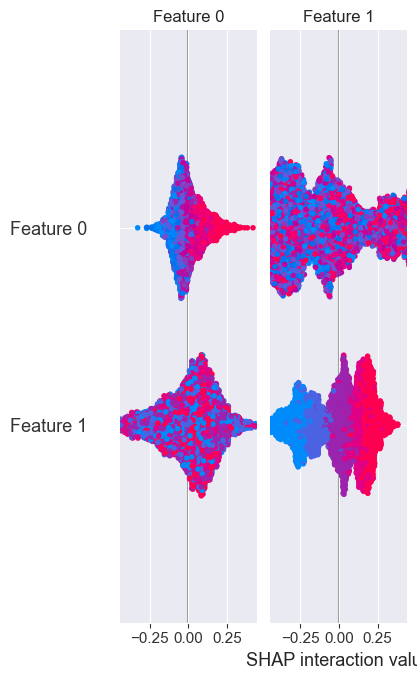

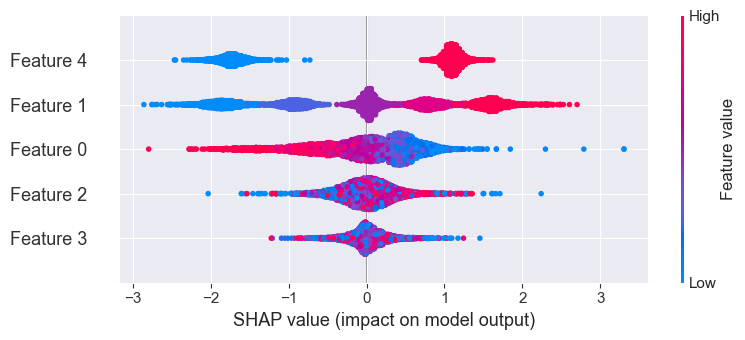

In [18]:
# Interpretability with SHAP
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test)
shap.summary_plot(shap_values_rf, X_test)

explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)
shap.summary_plot(shap_values_xgb, X_test)

In [19]:
# Save the best model (based on ROC-AUC or other evaluation metrics)
best_model = rf if rf_roc_auc > xgb_roc_auc else xgb_model
with open('student_depression_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

In [20]:
# Display final metrics
print(f"Random Forest ROC-AUC: {rf_roc_auc}")
print(f"XGBoost ROC-AUC: {xgb_roc_auc}")

Random Forest ROC-AUC: 0.7600369434592416
XGBoost ROC-AUC: 0.7850370423090255
